# U-Net from Scratch

**References**

[1] Ronneberger, O., Fischer, P., & Brox, T. (2015, October). U-net: Convolutional networks for biomedical image segmentation. In International Conference on Medical image computing and computer-assisted intervention (pp. 234-241). Cham: Springer international publishing.

## Required Imports

In [26]:
import os
import math
import random

import numpy as np
import matplotlib.pyplot as plt
import cv2
import scipy.ndimage as ndimage
from scipy.ndimage import label, distance_transform_edt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchinfo import summary

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torch.utils.data import Dataset, DataLoader

## Data Preprocessing

### Loading from Data

#### The Image

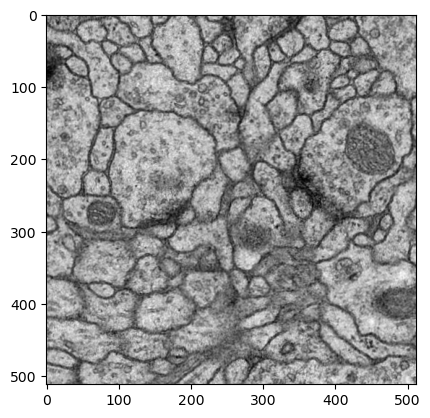

In [27]:
image = cv2.imread('../../data/isbi2012challenge/train/imgs/frame_0001.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')

#### The Mask Label

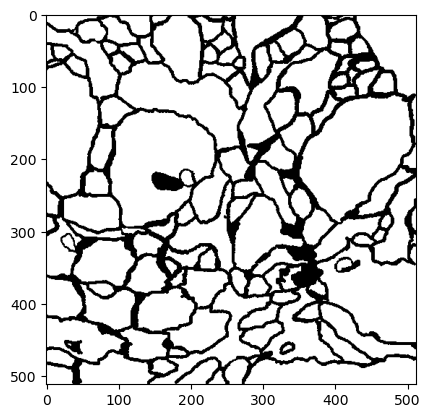

In [28]:
mask = cv2.imread('../../data/isbi2012challenge/train/labels/frame_0001.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(mask, cmap='gray')

### Data Augmentation: The Elastic Deformation

Because the training data for the task is very limited, the paper proposes to use *Elastic Deformation* to the available training images, which allows the network to learn invariance to such deformations without the need to see these transformations in the annotated image corpus. (as in the original unet paper).

In the case of microscopical images, we majorly need shift and rotation invariance as well as robustness to deformations and gray value variations. Specifically, the paper proposes to augment the training dataset by generating smooth deformations using random displacement vectors on a coarse $3 \times 3$ grid, which are sampled from a Gaussian distribution with $10$ pixels standard deviation. The pixelwise displacements are computed using *bicubic interpolation*. Also note that the dropout layers at the end of the contracting path perform further data augmentation implicitly.

In [29]:
def elastic_transform(image, grid_size=3, std=10):
    """
    Perform elastic deformation on the input grayscale image. This is an explanatory implementation of
    the elastic deformation process. We will use albumentations library to perform the elastic deformation
    in the data pipeline.
    
    Args:
        image: grayscale image in numpy array of shape (H, W)
        grid_size: size of the grid for deformation, default to 3 x 3 grid
        std: standard deviation of the Gaussian distribution, default to 10 pixels
        
    Returns:
        deformed_image: numpy array of shape (H, W, C)
    """
    h, w = image.shape

    # 3 x 3 coarse grid of random displacement vectors sampled from Gaussian
    # distribution with std = 10 pixels
    x_displacements = np.random.normal(0, std, size=(grid_size, grid_size)) # 3 x 3 grid for x displacements
    y_displacements = np.random.normal(0, std, size=(grid_size, grid_size)) # 3 x 3 grid for y displacements

    # create a grid of coordinates
    x_coordinates = np.linspace(start=0, stop=grid_size - 1, num=w)
    y_coordinates = np.linspace(start=0, stop=grid_size - 1, num=h)
    grid = np.meshgrid(x_coordinates, y_coordinates, indexing='ij') # using indexing='ij' to match the shape of the displacements

    # compute the displacement values
    dx = ndimage.map_coordinates(x_displacements, grid)
    dy = ndimage.map_coordinates(y_displacements, grid)

    # create a coordinate grid for the deformed image
    output_coordinates_y, output_coordinates_x = np.meshgrid(np.arange(h), np.arange(w), indexing='ij') # output image coordinates

    # apply displacements to the coordinates of the deformed image
    output_coordinates_y = output_coordinates_y + dy
    output_coordinates_x = output_coordinates_x + dx

    # compute the pixel values of the deformed image using bicubic interpolation
    deformed_image = ndimage.map_coordinates(image, [output_coordinates_y, output_coordinates_x])

    return deformed_image

Deform a sample,

In [30]:
image.shape

(512, 512)

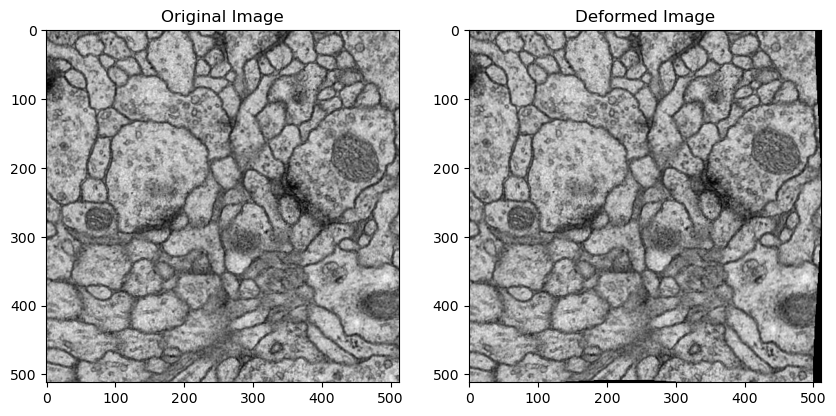

In [31]:
deformed_image = elastic_transform(image)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(deformed_image, cmap='gray')
axes[1].set_title('Deformed Image')
plt.show()

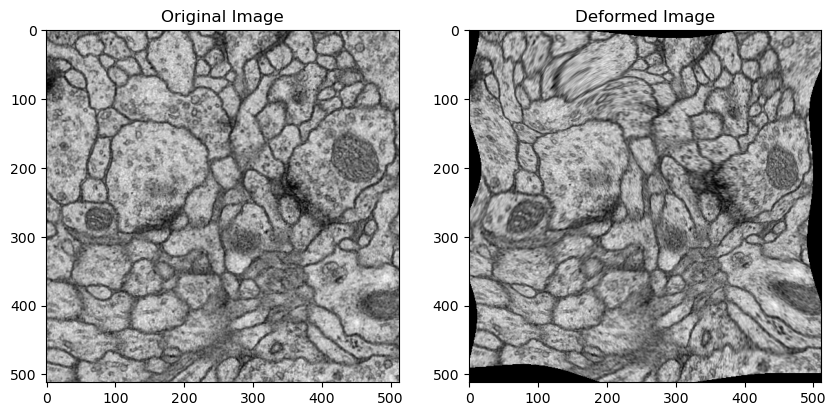

In [32]:
# another deformation
deformed_image = elastic_transform(image, grid_size=6, std=20)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(deformed_image, cmap='gray')
axes[1].set_title('Deformed Image')
plt.show()

### Define Dataloaders

#### The Train and Test Data Transforms

In [33]:
warmup_train_transform = A.Compose([
    # 1. Resize
    A.Resize(height=512, width=512),

    # 2. Light geometric augmentations for stable early training
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    # 3. Normalization and Conversion to Tensor
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
], additional_targets={"weight_map": "mask"})

train_transform = A.Compose([
    # 1. Resize
    A.Resize(height=512, width=512),

    # 2. Light geometric augmentations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    # 3. Apply at most one stronger warp, and do it less often.
    A.OneOf([
        A.ElasticTransform(alpha=1, sigma=10, p=1.0),
        A.GridDistortion(distort_limit=0.15, p=1.0),
        A.Affine(
            translate_percent={"x": (-0.03, 0.03), "y": (-0.03, 0.03)},
            scale=(0.95, 1.05),
            rotate=(-15, 15),
            p=1.0
        ),
    ], p=0.2),

    # 4. Normalization and Conversion to Tensor
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
], additional_targets={"weight_map": "mask"})

In [34]:
test_transform = A.Compose([
    A.Resize(height=512, width=512),
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
])

#### The Dataset Classes

In [35]:
class ISBI2012Dataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, weight_map_cache=None, return_weight_map=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))
        self.weight_map_cache = weight_map_cache or {}
        self.return_weight_map = return_weight_map

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_name = self.images[idx]

        image_path = os.path.join(self.image_dir, image_name)
        mask_path = os.path.join(self.mask_dir, image_name)

        # 1. Load the image and mask and convert to numpy arrays for albumentations
        image = np.array(cv2.imread(image_path))
        mask = np.array(cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE))

        # The ISBI masks are binary images with values {0, 255}; remap them to class ids {0, 1}.
        mask = (mask > 0).astype(np.uint8)

        # 2. Apply the transformations
        if self.return_weight_map:
            weight_map = self.weight_map_cache[image_name].copy()

            if self.transform is not None:
                augmented = self.transform(image=image, mask=mask, weight_map=weight_map)
                image = augmented['image']
                mask = augmented['mask']
                weight_map = augmented['weight_map']

            if not torch.is_tensor(mask):
                mask = torch.as_tensor(mask)
            if not torch.is_tensor(weight_map):
                weight_map = torch.as_tensor(weight_map)

            return image, mask.long(), weight_map.float()

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask)

        # 3. Return the image and mask, ensure the mask is long tensor for cross-entropy loss
        # and the image is already a FloatTensor from the ToTensorV2() transform in the transform pipeline
        return image, mask.long()

In [36]:
train_dataset = ISBI2012Dataset(
    image_dir='../../data/isbi2012challenge/train/imgs',
    mask_dir='../../data/isbi2012challenge/train/labels',
    transform=train_transform
)

test_dataset = ISBI2012Dataset(
    image_dir='../../data/isbi2012challenge/test/imgs',
    mask_dir='../../data/isbi2012challenge/test/labels',
    transform=test_transform
)

#### The Dataloaders

In [37]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [38]:
# Test the Dataloaders
for batch in train_loader:
    if len(batch) == 3:
        images, masks, weight_maps = batch
        print(images.shape)
        print(masks.shape)
        print(weight_maps.shape)
    else:
        images, masks = batch
        print(images.shape)
        print(masks.shape)

    print(torch.unique(masks))
    break

torch.Size([8, 3, 512, 512])
torch.Size([8, 512, 512])
tensor([0, 1])


## The U-Net Model Architecture

Here we implement the U-Net architecture from the original paper.

![U-Net Model Architecture](./imgs/unet.png)

The model architecture consists of a contracting path (left side) and an expansive path (right side),

- Contractive Path: similar to a typical convolutional neural network, consisting of two repeated $3 \times 3$ unpadded convolutions, each followed by a ReLU and a $2 \times 2$ max pooling operation with stride $2$ for downsampling, where at each downsampling step we double the number of feature channels.
- Expansive Path: at each step in the expansive path, we perform upsampling of the feature map followed by a $2 x 2$ convolution (*"up-convolution"*) that halves the number of feature channels, we also concatenate the upsampled feature map with the cropped feature map from the corresponding step in the contractive path, and two $3 \times 3$ convolutions, each followed by a ReLU. **Note** that the cropping is necessary due to the loss of border pixels in every convolution.

At the final layer a $1 \times 1$ convolution is used to map each $64$ component feature vector to a desired number of classes. The U-Net has a total of $23$ convolutional layers.

In [39]:
class Contraction(nn.Module):
    """
    Contractive Path
    """
    def __init__(self, in_channels, out_channels):
        super(Contraction, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        downsampled = self.relu(x) # we save the downsampled output for shortcut connection in the expansive path
        pooled = self.maxpool(downsampled)
        return downsampled, pooled

In [40]:
class Expansion(nn.Module):
    """
    Expansive Path
    """
    def __init__(self, in_channels, out_channels):
        super(Expansion, self).__init__()

        self.upconv1 = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, downsampled):
        x = self.upconv1(x)
        x = torch.cat([x, downsampled], dim=1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        return x

In [41]:
class UNet(nn.Module):
    """
    U-Net Model
    """
    def __init__(self, in_channels, num_classes):
        super(UNet, self).__init__()

        self.contraction1 = Contraction(in_channels, 64)
        self.contraction2 = Contraction(64, 128)
        self.contraction3 = Contraction(128, 256)
        self.contraction4 = Contraction(256, 512)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.expansion1 = Expansion(1024, 512)
        self.expansion2 = Expansion(512, 256)
        self.expansion3 = Expansion(256, 128)
        self.expansion4 = Expansion(128, 64)

        self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        downsampled1, pool1 = self.contraction1(x)
        downsampled2, pool2 = self.contraction2(pool1)
        downsampled3, pool3 = self.contraction3(pool2)
        downsampled4, pool4 = self.contraction4(pool3)

        bottleneck = self.bottleneck(pool4)

        upsampled1 = self.expansion1(bottleneck, downsampled4)
        upsampled2 = self.expansion2(upsampled1, downsampled3)
        upsampled3 = self.expansion3(upsampled2, downsampled2)
        upsampled4 = self.expansion4(upsampled3, downsampled1)

        return self.output_conv(upsampled4)

In [42]:
# Test the U-Net model
model = UNet(in_channels=3, num_classes=10)
x = torch.randn(1, 3, 512, 512)
output = model(x)
print(output.shape)

torch.Size([1, 10, 512, 512])


In [43]:
summary(model, input_size=(1, 3, 512, 512))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 10, 512, 512]         --
├─Contraction: 1-1                       [1, 64, 512, 512]         --
│    └─Conv2d: 2-1                       [1, 64, 512, 512]         1,792
│    └─ReLU: 2-2                         [1, 64, 512, 512]         --
│    └─Conv2d: 2-3                       [1, 64, 512, 512]         36,928
│    └─ReLU: 2-4                         [1, 64, 512, 512]         --
│    └─MaxPool2d: 2-5                    [1, 64, 256, 256]         --
├─Contraction: 1-2                       [1, 128, 256, 256]        --
│    └─Conv2d: 2-6                       [1, 128, 256, 256]        73,856
│    └─ReLU: 2-7                         [1, 128, 256, 256]        --
│    └─Conv2d: 2-8                       [1, 128, 256, 256]        147,584
│    └─ReLU: 2-9                         [1, 128, 256, 256]        --
│    └─MaxPool2d: 2-10                   [1, 128, 128, 128]        --

## Training

### Define the Loss Functions

The original U-Net paper uses an energy based pixelwise `SoftMax` + weighted `CrossEntropy` loss function. Specifically, the energy based loss function is calculated using a pixelwise `SoftMax` over the final feature map in combination with the `CrossEntropy` loss function, where the `SoftMax` function is defined as,
$$
p_k (\boldsymbol{x}) = \frac{\exp (a_k (\boldsymbol{x}))}{\sum_{k' = 1}^K \exp (a_{k'} (\boldsymbol{x}))}
$$
where $a_k (\boldsymbol{x})$ denotes the activation in feature channel $k$ at the pixel position $\boldsymbol{x} \in \Omega,\: \Omega \subset \mathbb{Z}^2$, $K$ is the number of classes and $p_k( \boldsymbol{x})$ is the approximated maximum-function, *i.e.*, $p_k (\boldsymbol{x}) \sim 1$ for the $k$ that has the maximum activation $a_k (\boldsymbol{x})$ and $p_k (\boldsymbol{x}) \approx 0$ for all other $k$. The `CrossEntropy` then penalizes at each position the deviation of $p_{l(\boldsymbol{x})} (\boldsymbol{x})$ from $1$ using
$$
E = \sum_{\boldsymbol{x} \in \Omega} \omega(\boldsymbol{x}) \log (p_{l(\boldsymbol{x})} (\boldsymbol{x}))
$$
where $l: \Omega \mapsto \{1, \cdots, K \}$ is the true label of each pixel and $\omega: \Omega \mapsto \mathbb{R}$ is a weight map that we introduced to give some pixels more importance in the training. The weight map is precomputed for each ground truth segmentation to compensate the different frequency of pixels from a certain class in the training dataset, and to force the network to learn the small separation borders between touching cells, which is calculated using morphological operations,
$$
\omega (\boldsymbol{x}) = \omega_c (\boldsymbol{x}) + \omega_0 \cdot \exp \left( - \frac{(d_1 (\boldsymbol{x}) + d_2 (\boldsymbol{x}))^2}{2 \sigma^2} \right)
$$
where $\omega_c: \Omega \mapsto \mathbb{R}$ is the weight map to balance the class frequencies, and $d_1: \Omega \mapsto \mathbb{R}$ denotes the distance to the border of the nearest cell and $d_2: \Omega \mapsto \mathbb{R}$ the distance to the border of the second nearest cell. In our experiments we set $\omega_0 = 10$ and $\sigma \approx 5$ pixels.

In [44]:
def compute_weight_map(mask, w_0=10.0, sigma=5.0):
    """
    Compute the weight map for the U-Net loss function, see:
    - Ronneberger, O., Fischer, P., & Brox, T. (2015, October). U-net: Convolutional networks for biomedical image segmentation.
        In International Conference on Medical image computing and computer-assisted intervention (pp. 234-241). Cham: Springer international publishing.

    Args:
        mask: H X W ndarray with 0 = background and > 0 = foreground
        w_0: weight for the border distance term, default to 10 in the paper
        sigma: width / standard deviation of the border term, default to 5 in the paper

    Returns:
        weight_map: H X W float32 ndarray
    """
    # Treat any non-zero class as foreground, and keep counts in signed integer space.
    foreground_mask = (mask > 0).astype(np.uint8)

    # --- Class Frequency Balance Weight Map w_c(x): Inversely Proportional to the Frequency of Each Class ---
    num_foreground = int(foreground_mask.sum())
    num_background = int(foreground_mask.size - num_foreground)
    w_c = np.zeros(foreground_mask.shape, dtype=np.float32)

    if num_foreground > 0:
        w_c[foreground_mask == 1] = 0.5 * foreground_mask.size / num_foreground
    if num_background > 0:
        w_c[foreground_mask == 0] = 0.5 * foreground_mask.size / num_background

    # --- Border Separation ---
    labeled, num_cells = label(foreground_mask)
    w_borders = np.zeros(foreground_mask.shape, dtype=np.float32)

    if num_cells > 1:
        # For each cell, compute the distance from every pixel to that cell.
        # Using labeled != i makes background pixels carry the distance to object i,
        # which is what the original U-Net border weighting expects.
        distances = np.stack(
            [distance_transform_edt(labeled != i) for i in range(1, num_cells + 1)],
            axis=0
        )

        # Only keep the two smallest distances per pixel.
        d1, d2 = np.partition(distances, kth=1, axis=0)[:2]

        # compute the weight map for the border pixels
        w_borders = w_0 * np.exp(-((d1 + d2) ** 2) / (2 * sigma**2))

        # the border term is only meant to push apart touching cells
        w_borders[foreground_mask == 1] = 0

    # Normalize so the weighted loss stays on a comparable scale across images.
    weight_map = w_c + w_borders
    weight_map /= weight_map.mean() + 1e-8
    return weight_map.astype(np.float32)

In [45]:
class UNetLoss(nn.Module):
    """
    Combined weighted cross-entropy + soft Dice loss for binary segmentation.
    """
    def __init__(self, ce_weight=0.5, dice_weight=0.5, smooth=1e-6):
        super().__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth

    def forward(self, inputs, targets, weight_map):
        """
        Args:
            inputs: B x C x H x W float32 tensor of raw score logits
            targets: B x H x W int64 tensor with labels in [0, C - 1]
            weight_map: B x H x W float32 tensor, the precomputed pixel weighting map
        Returns:
            loss: scalar tensor, the combined loss value
        """
        if inputs.shape[1] != 2:
            raise ValueError("UNetLoss currently expects binary segmentation logits with 2 output channels.")

        if targets.ndim == 4 and targets.size(1) == 1:
            targets = targets.squeeze(1)

        if not torch.is_tensor(weight_map):
            weight_map = torch.as_tensor(weight_map, device=inputs.device, dtype=inputs.dtype)
        else:
            weight_map = weight_map.to(device=inputs.device, dtype=inputs.dtype)

        # Weighted cross-entropy keeps the original U-Net border emphasis.
        log_probs = F.log_softmax(inputs, dim=1)
        log_probs_true = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        weighted_ce = (-weight_map * log_probs_true).sum() / weight_map.sum().clamp_min(self.smooth)

        # Soft Dice on the foreground class discourages fragmented masks.
        foreground_probs = torch.softmax(inputs, dim=1)[:, 1]
        foreground_targets = (targets == 1).float()

        foreground_probs = foreground_probs.reshape(foreground_probs.shape[0], -1)
        foreground_targets = foreground_targets.reshape(foreground_targets.shape[0], -1)

        intersection = (foreground_probs * foreground_targets).sum(dim=1)
        denominator = foreground_probs.sum(dim=1) + foreground_targets.sum(dim=1)
        dice_score = (2.0 * intersection + self.smooth) / (denominator + self.smooth)
        dice_loss = 1.0 - dice_score.mean()

        return self.ce_weight * weighted_ce + self.dice_weight * dice_loss

### The Training Loop

In [46]:
num_epochs = 100
num_classes = 2 # 0 = background, 1 = cell
batch_size = 8
warmup_epochs = 3
ce_weight = 0.5
dice_weight = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_image_dir = '../../data/isbi2012challenge/train/imgs'
train_mask_dir = '../../data/isbi2012challenge/train/labels'

train_weight_map_cache = {}
for image_name in sorted(os.listdir(train_image_dir)):
    mask_path = os.path.join(train_mask_dir, image_name)
    mask = np.array(cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE))
    mask = (mask > 0).astype(np.uint8)
    train_weight_map_cache[image_name] = compute_weight_map(mask)

train_dataset = ISBI2012Dataset(
    image_dir=train_image_dir,
    mask_dir=train_mask_dir,
    transform=warmup_train_transform,
    weight_map_cache=train_weight_map_cache,
    return_weight_map=True
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model = UNet(in_channels=3, num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
criterion = UNetLoss(ce_weight=ce_weight, dice_weight=dice_weight)
max_grad_norm = 1.0

print("Training Configurations:")
print(f"Training on {len(train_loader.dataset)} samples")
print(f"Using device: {device}")
print(f"Number of epochs: {num_epochs}")
print(f"Warmup epochs: {warmup_epochs}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Batch size: {train_loader.batch_size}")
print(f"Number of classes: {num_classes}")
print(f"Precomputed weight maps: {len(train_weight_map_cache)}")
print(f"Loss: weighted CE + Dice (ce_weight={ce_weight}, dice_weight={dice_weight})")
print(f"Max grad norm: {max_grad_norm}")
print(f"Model Architecture: {summary(model, input_size=(1, 3, 512, 512))}")
print("="*100)

Training Configurations:
Training on 30 samples
Using device: cuda
Number of epochs: 100
Warmup epochs: 3
Learning rate: 0.0001
Batch size: 8
Number of classes: 2
Precomputed weight maps: 30
Max grad norm: 1.0
Model Architecture: ==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 2, 512, 512]          --
├─Contraction: 1-1                       [1, 64, 512, 512]         --
│    └─Conv2d: 2-1                       [1, 64, 512, 512]         1,792
│    └─ReLU: 2-2                         [1, 64, 512, 512]         --
│    └─Conv2d: 2-3                       [1, 64, 512, 512]         36,928
│    └─ReLU: 2-4                         [1, 64, 512, 512]         --
│    └─MaxPool2d: 2-5                    [1, 64, 256, 256]         --
├─Contraction: 1-2                       [1, 128, 256, 256]        --
│    └─Conv2d: 2-6                   

Training on 30 samples
Epoch 1/100, Loss: 0.6580, Max Batch Loss: 0.6604, Mode: warmup, Learning Rate: 0.000100
Epoch 2/100, Loss: 0.6511, Max Batch Loss: 0.6530, Mode: warmup, Learning Rate: 0.000100
Epoch 3/100, Loss: 0.6434, Max Batch Loss: 0.6465, Mode: warmup, Learning Rate: 0.000100
Epoch 4/100, Loss: 0.6346, Max Batch Loss: 0.6401, Mode: full_aug, Learning Rate: 0.000100
Epoch 5/100, Loss: 0.6252, Max Batch Loss: 0.6299, Mode: full_aug, Learning Rate: 0.000100
Epoch 6/100, Loss: 0.6175, Max Batch Loss: 0.6287, Mode: full_aug, Learning Rate: 0.000100
Epoch 7/100, Loss: 0.6092, Max Batch Loss: 0.6195, Mode: full_aug, Learning Rate: 0.000100
Epoch 8/100, Loss: 0.5968, Max Batch Loss: 0.6064, Mode: full_aug, Learning Rate: 0.000100
Epoch 9/100, Loss: 0.5861, Max Batch Loss: 0.5889, Mode: full_aug, Learning Rate: 0.000100
Epoch 10/100, Loss: 0.5733, Max Batch Loss: 0.5785, Mode: full_aug, Learning Rate: 0.000100
Epoch 11/100, Loss: 0.5573, Max Batch Loss: 0.5635, Mode: full_aug, Lear

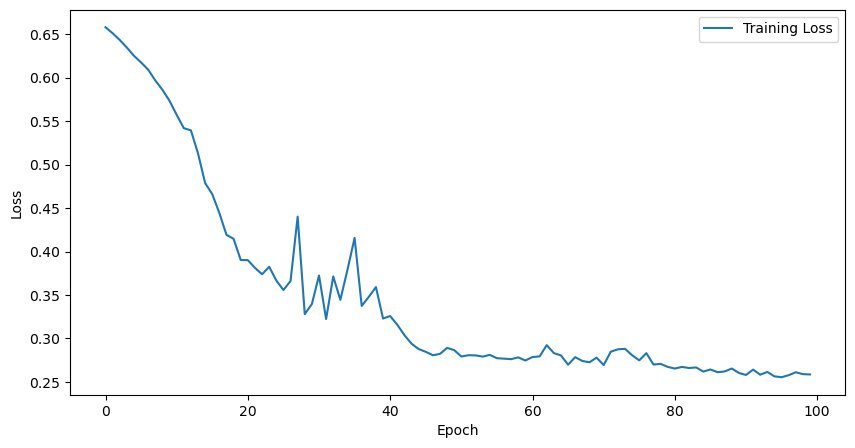

In [47]:
train_losses = []

print(f"Training on {len(train_loader.dataset)} samples")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    epoch_batch_losses = []

    # Start with light augmentation so the model learns the basic segmentation task first.
    train_loader.dataset.transform = warmup_train_transform if epoch < warmup_epochs else train_transform

    for batch_idx, (images, masks, weight_maps) in enumerate(train_loader):
        images = images.to(device)
        masks = masks.to(device).long()
        weight_maps = weight_maps.to(device=device, dtype=images.dtype)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks, weight_maps)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        batch_loss = loss.item()
        total_loss += batch_loss
        epoch_batch_losses.append(batch_loss)

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    scheduler.step(avg_loss)
    current_lr = optimizer.param_groups[0]['lr']
    train_mode = 'warmup' if epoch < warmup_epochs else 'full_aug'

    print(
        f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}, "
        f"Max Batch Loss: {max(epoch_batch_losses):.4f}, Mode: {train_mode}, "
        f"Learning Rate: {current_lr:.6f}"
    )

print("Training complete! :)")

# Save the model
torch.save(model.state_dict(), 'unet_model.pth')
print("Model saved to 'unet_model.pth' :)")

# Plot the training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Evaluation

In [48]:
def evaluate_model(predictions, targets, num_classes):
    """
    Computes mean IoU and pixel accuracy for a batch.

    Args:
        predictions: raw logits of shape B x C x H x W or class predictions of shape B x H x W
        targets: ground-truth labels of shape B x H x W (or B x 1 x H x W)
        num_classes: int, the number of classes

    Returns:
        iou: float, the mean IoU score across classes present in the batch
        pixel_accuracy: float, the pixel accuracy
    """
    if targets.ndim == 4 and targets.size(1) == 1:
        targets = targets.squeeze(1)

    if predictions.ndim == 4:
        predictions = predictions.argmax(dim=1)

    if predictions.shape != targets.shape:
        raise ValueError(
            f"Predictions shape {tuple(predictions.shape)} does not match targets shape {tuple(targets.shape)}"
        )

    predictions = predictions.reshape(-1)
    targets = targets.reshape(-1)

    iou_scores = []

    for cls in range(num_classes):
        pred_mask = predictions == cls
        target_mask = targets == cls

        intersection = (pred_mask & target_mask).sum().item()
        union = pred_mask.sum().item() + target_mask.sum().item() - intersection

        if union != 0:
            iou_scores.append(intersection / union)

    iou = float(np.mean(iou_scores)) if iou_scores else float("nan")
    pixel_accuracy = (predictions == targets).float().mean().item()

    return iou, pixel_accuracy

### Evaluation Loop

In [49]:
print("Evaluating the model on the test set...")

model.eval()

test_iou = 0.0
test_pixel_accuracy = 0.0
num_batches = 0

with torch.no_grad():
    for batch_idx, (images, masks) in enumerate(test_loader):
        images = images.to(device)
        masks = masks.to(device).long()

        outputs = model(images)
        
        iou, pixel_accuracy = evaluate_model(outputs, masks, num_classes)
        test_iou += iou
        test_pixel_accuracy += pixel_accuracy
        num_batches += 1

test_iou /= num_batches
test_pixel_accuracy /= num_batches

print(f"Test IoU: {test_iou:.4f}, Test Pixel Accuracy: {test_pixel_accuracy:.4f}")
print("Evaluation complete! :)")

Evaluating the model on the test set...
Test IoU: 0.6651, Test Pixel Accuracy: 0.8140
Evaluation complete! :)


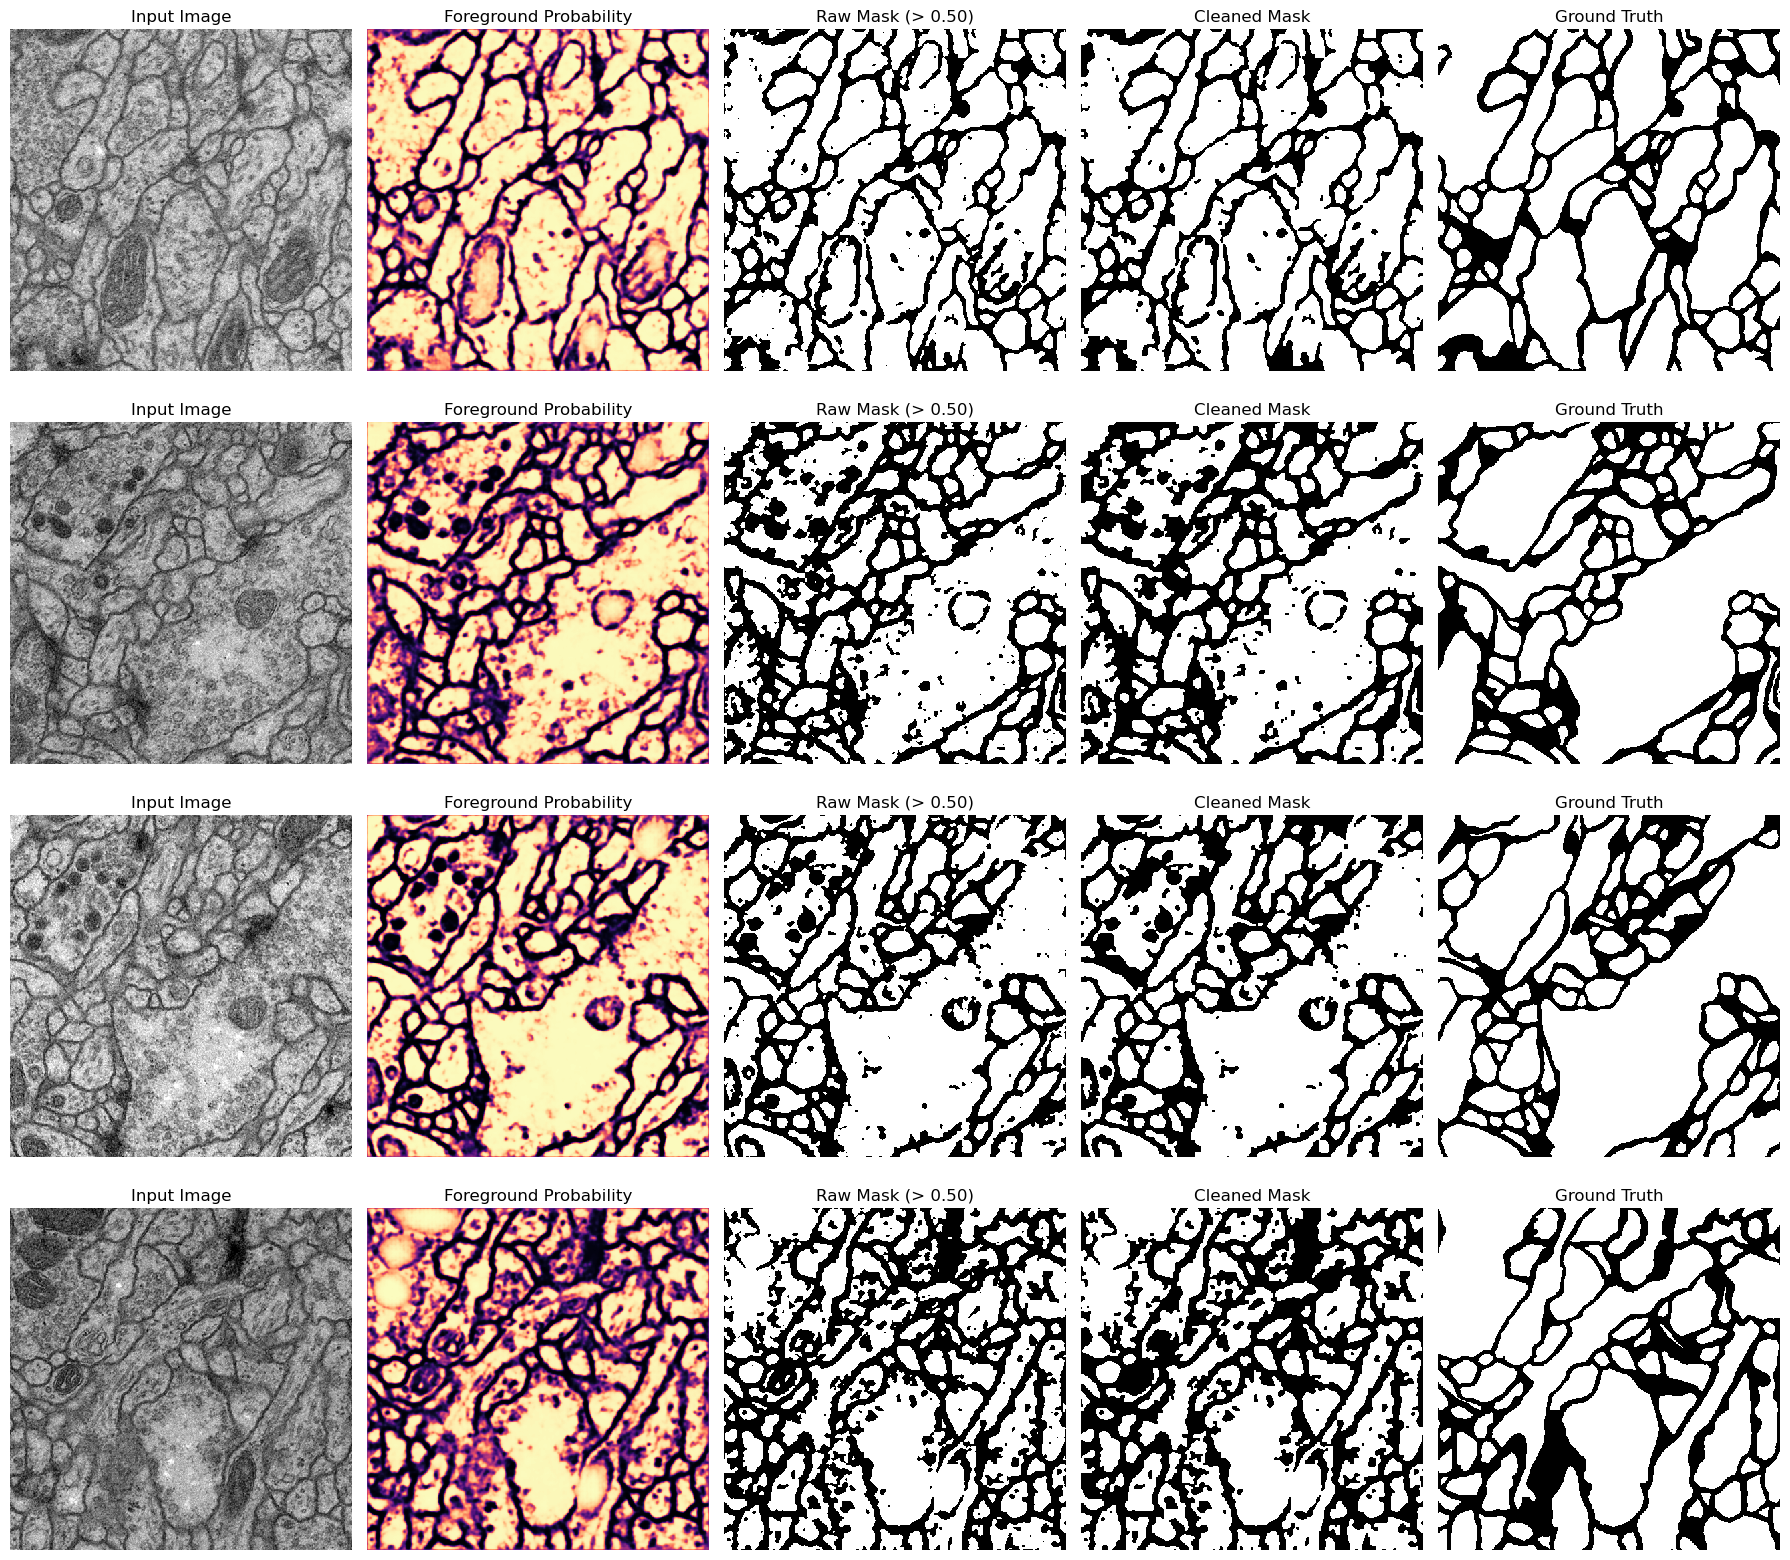

In [50]:
# fix random seed
random.seed(42)

def remove_small_components(mask, min_component_size=128):
    """
    Remove tiny connected components from a binary mask.
    """
    labeled_mask, num_components = label(mask)
    cleaned_mask = np.zeros_like(mask, dtype=np.uint8)

    for component_id in range(1, num_components + 1):
        component = labeled_mask == component_id
        if component.sum() >= min_component_size:
            cleaned_mask[component] = 1

    return cleaned_mask

# visualize the predictions
def visualize_predictions(
    model,
    test_loader,
    device,
    num_samples=4,
    threshold=0.5,
    min_component_size=128,
    kernel_size=3,
):
    """
    Visualizes binary-segmentation predictions and separates model uncertainty
    from thresholding / post-processing artifacts.
    """
    model.eval()

    if model.output_conv.out_channels != 2:
        raise ValueError("This visualization helper assumes binary segmentation with 2 classes.")

    sample_indices = random.sample(range(len(test_loader.dataset)), k=min(num_samples, len(test_loader.dataset)))
    test_samples = [test_loader.dataset[idx] for idx in sample_indices]

    images = torch.stack([sample[0] for sample in test_samples]).to(device)
    masks = torch.stack([sample[1] for sample in test_samples]).long().to(device)

    with torch.no_grad():
        outputs = model(images)
        foreground_probs = torch.softmax(outputs, dim=1)[:, 1]

    probs_np = foreground_probs.cpu().numpy()
    targets = masks.cpu().numpy()
    images_np = images.detach().cpu().numpy()

    kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)

    fig, axes = plt.subplots(len(test_samples), 5, figsize=(18, 4 * len(test_samples)))
    if len(test_samples) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(len(test_samples)):
        image_np = np.clip(images_np[i].transpose(1, 2, 0), 0.0, 1.0)
        probability_map = probs_np[i]
        raw_mask = (probability_map > threshold).astype(np.uint8)
        cleaned_mask = remove_small_components(raw_mask, min_component_size=min_component_size)
        cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_OPEN, kernel)
        cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, kernel)

        axes[i, 0].imshow(image_np, interpolation="nearest")
        axes[i, 0].set_title("Input Image")
        axes[i, 1].imshow(probability_map, cmap="magma", vmin=0.0, vmax=1.0, interpolation="nearest")
        axes[i, 1].set_title("Foreground Probability")
        axes[i, 2].imshow(raw_mask, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        axes[i, 2].set_title(f"Raw Mask (> {threshold:.2f})")
        axes[i, 3].imshow(cleaned_mask, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        axes[i, 3].set_title("Cleaned Mask")
        axes[i, 4].imshow(targets[i], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        axes[i, 4].set_title("Ground Truth")

        for ax in axes[i]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

# visualize the predictions
visualize_predictions(model, test_loader, device, threshold=0.5, min_component_size=128)